# di.simtick: two configuration examples

The simplest run needs only five values describing a stock, plus a date:

```q
simtick.quick[`NVDA;200.0;0.01;0.42;20000;2026.08.18]
```

Everything else comes from configuration files. A run of `di.simtick` reads one flat dictionary of several dozen parameters (Example 1 counts them), but nobody sets them one by one: the dictionary is **composed from four layers**, each read from its own file, a later layer overriding an earlier one.

| Layer | What it holds | Shipped as |
|---|---|---|
| market | how a market works: session times, tick size, how trades cluster and how activity varies through the day, trade sizes, spreads, venues, impact | `di/simtick/config/markets/us_largecap.json` |
| instrument | what makes a stock itself: `sym`, `price`, `drift`, `vol`, `tradesperday`, plus any market key it overrides | `di/simtick/config/instruments.csv` |
| scenario | what makes a day type: multipliers of vol, trades and spread, the **jump model**, the day-to-day regime | `di/simtick/config/scenarios.csv` |
| run | what changes between two runs: `tradingdate`, `seed`, `generatequotes` | a dictionary |

The market file also carries default run values (seed 42, quotes returned), so that `quick` gives the same data every time it is called with the same arguments. When several stocks are simulated with `di.simmarket`, each stock can have its own scenario, for example NVDA on `normal` and PG on `volatile`.

**Example 1** generates one day of NVDA from the five instrument values and the date. **Example 2** switches the price model from GBM to jump diffusion and sets the jump parameters.


In [1]:
import os
import pykx as kx
import matplotlib.pyplot as plt

# the modules are found on QPATH (see the root README); when di.simtick is not
# on it, the repository this notebook sits in is added to the search path
try:
    kx.q('simtick:use`di.simtick')
except kx.QError:
    kx.q('{.Q.m.SP,:enlist x}', os.path.abspath(os.path.join('..', '..', '..')).encode())
    kx.q('simtick:use`di.simtick')

# the shipped layer files, loaded once
kx.q('f:simtick.files[]')
kx.q('market:simtick.loadmarket f`market')
kx.q('instruments:simtick.loadinstruments f`instruments')
kx.q('scenarios:simtick.loadscenarios f`scenarios')

def show(qexpr):
    # a q table as a DataFrame, with q strings decoded
    df = kx.q(qexpr).pd()
    return df.apply(lambda c: c.map(lambda v: v.decode() if isinstance(v, bytes) else v))

# the three files, relative to the module di.simtick.config
{k: v.split('/config/')[-1] for k, v in kx.q('f').py().items()}


Welcome to KDB-X Community Edition!
For Community support, please visit https://kx.com/slack
Tutorials can be found at https://github.com/KxSystems/tutorials
Ready to go beyond the Community Edition? Email preview@kx.com



{'market': 'markets/us_largecap.json',
 'instruments': 'instruments.csv',
 'scenarios': 'scenarios.csv'}

## Example 1: NVDA at $200, drift 1%, vol 42%, 20,000 trades a day, on 2026.08.18

`simtick.quick` takes the five instrument values and the date. Everything else comes from the shipped market file and the `normal` scenario, and the market file's run defaults (seed 42, quotes returned) make the run reproducible: the same call always gives the same data.

Expect about 20,000 trades plus the two auction prints, and about 80,000 quotes, since the market file sets 4 quote updates per trade. A single day varies a little around 20,000, because trades arrive in clusters. 20,000 trades keeps the example quick; a real NVDA day is much busier.


In [2]:
kx.q('r1:simtick.quick[`NVDA;200.0;0.01;0.42;20000;2026.08.18]')
print('trades:', kx.q('count r1`trade').py(), ' quotes:', kx.q('count r1`quote').py())
display(kx.q('5#r1`trade').pd())
display(kx.q('5#r1`quote').pd())

# reproducible: the same call gives exactly the same data
kx.q('r1b:simtick.quick[`NVDA;200.0;0.01;0.42;20000;2026.08.18]')
print('same call, identical data:', kx.q('r1~r1b').py())


trades: 19685  quotes: 79421


,sym,time,seq,price,qty,aggressor,cond,venue
0,NVDA,2026-08-18 09:30:00.000000000,2,200.00,29195,,O,XNAS
1,NVDA,2026-08-18 09:30:01.387179908,4,200.00,35,B,I,TRF
2,NVDA,2026-08-18 09:30:02.525033901,6,199.98,92,S,I,IEXG
3,NVDA,2026-08-18 09:30:03.211555925,8,199.99,114,S,R,TRF
4,NVDA,2026-08-18 09:30:10.768177960,31,199.94,500,S,R,XNAS


,sym,time,seq,bid,ask,bidsize,asksize
0,NVDA,2026-08-18 09:30:00.000000000,1,199.98,200.02,100,400
1,NVDA,2026-08-18 09:30:00.268476549,3,199.96,200.00,700,200
2,NVDA,2026-08-18 09:30:01.451457592,5,199.98,200.02,500,700
3,NVDA,2026-08-18 09:30:02.790806316,7,199.99,200.00,200,400
4,NVDA,2026-08-18 09:30:03.458842411,9,199.96,199.97,100,500


same call, identical data: True


### What `quick` did

It built an instrument dictionary from the five values and composed it with the market, the `normal` scenario and a run dictionary holding the date. Writing the same thing out with `compose` shows the layers; the run is identical.

In [3]:
kx.q('ins1:`sym`price`drift`vol`tradesperday!(`NVDA;200.0;0.01;0.42;20000)')
kx.q('run1:(enlist `tradingdate)!enlist 2026.08.18')
kx.q('cfg1:simtick.compose[market;ins1;scenarios`normal;run1]')
print('compose then run equals quick:', kx.q('(simtick.run cfg1)~r1').py())
print('keys in the composed config:', kx.q('count cfg1').py())
kx.q('`sym`price`drift`vol`tradesperday`pricemodel`baseintensity`tradingdate`seed`generatequotes#cfg1').pd()

compose then run equals quick: True
keys in the composed config: 81


{'sym': 'NVDA',
 'price': 200.0,
 'drift': 0.01,
 'vol': 0.42,
 'tradesperday': 20000,
 'pricemodel': 'gbm',
 'baseintensity': 0.5959982971477183,
 'tradingdate': datetime.date(2026, 8, 18),
 'seed': 42,
 'generatequotes': True}

`baseintensity`, the base rate of the Hawkes process in trades per second, is not set by anyone: `compose` derives it from `tradesperday`. It takes out the follow-up trades that the clustering adds (a share `alpha/beta` of all trades) and spreads the rest over the session at the average level of the intraday profile. The essential five and the run keys, from `simtick.describe[]`:


In [4]:
show('`param`typ`layer`grp`description#select from simtick.describe[] where layer in `essential`run')

,param,typ,layer,grp,description
0,sym,S,essential,instrument,ticker
1,price,F,essential,instrument,price at the open of the (first) day
2,drift,F,essential,instrument,expected annual return (annualized drift of th...
3,vol,F,essential,instrument,annual volatility of the close-to-close return
4,tradesperday,J,essential,instrument,average number of trades per day (long-run ave...
5,tradingdate,D,run,run,the day simulated (the market file carries a d...
6,seed,J,run,run,random seed (0N = unseeded; the market file ca...
7,generatequotes,B,run,run,return the quotes as well as the trades (they ...


### A look at the day

The trade count lands near 20,000 (the Hawkes process is random, so not exactly), the spread is a whole number of ticks, and the mid follows the U-shaped activity of the day.

continuous trades: 19683  target tradesperday: 20000
mean spread in ticks: 1.244
open-to-close return: 0.0055


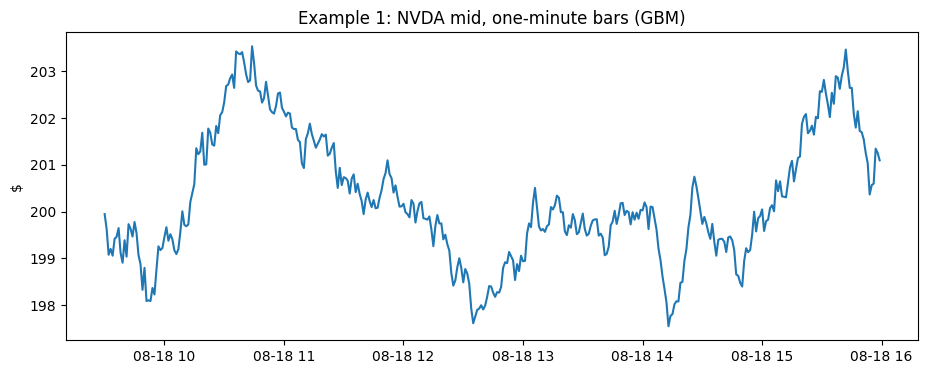

time,2026-08-18 09:30:00,2026-08-18 10:00:00,2026-08-18 10:30:00,2026-08-18 11:00:00,2026-08-18 11:30:00,2026-08-18 12:00:00,2026-08-18 12:30:00,2026-08-18 13:00:00,2026-08-18 13:30:00,2026-08-18 14:00:00,2026-08-18 14:30:00,2026-08-18 15:00:00,2026-08-18 15:30:00
trades,2289,1882,1573,1345,1097,1079,1007,1005,1148,1349,1412,1898,2599


In [5]:
kx.q('t1:select from r1`trade where cond in `R`I')          # continuous trades, auctions excluded
kx.q('q1:r1`quote')
print('continuous trades:', kx.q('count t1').py(), ' target tradesperday:', kx.q('cfg1`tradesperday').py())
print('mean spread in ticks:', round(kx.q('avg (q1[`ask]-q1`bid)%cfg1`ticksize').py(), 3))
print('open-to-close return:', round(kx.q('-1+(last t1`price)%first t1`price').py(), 5))
kx.q('m1:select mid:last 0.5*bid+ask by 0D00:01 xbar time from q1')
mid = kx.q('m1').pd()
plt.figure(figsize=(11,4)); plt.plot(mid.index, mid['mid']); plt.title('Example 1: NVDA mid, one-minute bars (GBM)'); plt.ylabel('$'); plt.show()
kx.q('select trades:count i by 0D00:30 xbar time from t1').pd().T

## Example 2: the same day with jump diffusion

The price model and the jump parameters are **scenario** keys (they describe a day type), and the trading burst that follows a jump is a **market** key (how a market reacts to news):

| Key | Layer | Meaning |
|---|---|---|
| `pricemodel` | scenario | `gbm` or `jump` |
| `jumpintensity` | scenario | jumps per day (a Poisson count) |
| `jumpmean` | scenario | mean of the log jump size |
| `jumpvol` | scenario | standard deviation of the log jump size |
| `jumpburst` | market | extra trades started by each jump; each can trigger follow-up trades, so the burst grows larger |
| `jumpburstminutes` | market | average delay of those extra trades after the jump, in minutes |

The shipped `jumpy` scenario row is one way to get there. Here we start from the `normal` row and set the jump keys ourselves, so it is clear which ones matter.

In [6]:
show('`param`layer`grp`description#select from simtick.describe[] where param in `pricemodel`jumpintensity`jumpmean`jumpvol`jumpburst`jumpburstminutes')

,param,layer,grp,description
0,jumpburst,market,arrivals,extra trade immigrants seeded by each jump (ea...
1,jumpburstminutes,market,arrivals,mean delay in minutes of those immigrants afte...
2,pricemodel,scenario,scenario,price model (`gbm or `jump)
3,jumpintensity,scenario,scenario,jump model: jumps per day
4,jumpmean,scenario,scenario,jump model: mean of the log jump size
5,jumpvol,scenario,scenario,jump model: standard deviation of the log jump...


In [7]:
# the scenario: jump diffusion with 3 jumps a day, no mean, 2% log-size spread
kx.q('sce2:scenarios`normal')
kx.q('sce2[`pricemodel]:`jump')
kx.q('sce2[`jumpintensity]:3f')
kx.q('sce2[`jumpmean]:0f')
kx.q('sce2[`jumpvol]:0.02')

# the burst: the market file starts 3000 extra trades per jump, sized for a 500,000-trade stock.
# With 20,000 trades a day three such bursts would be most of the day (3 x 3000 / (1 - alpha/beta) = 12,857 trades),
# so this instrument overrides the market key: 300 extra trades per jump
kx.q('ins2:ins1')
kx.q('ins2[`jumpburst]:300')

kx.q('cfg2:simtick.compose[market;ins2;sce2;run1]')
kx.q('`pricemodel`jumpintensity`jumpmean`jumpvol`jumpburst`jumpburstminutes`baseintensity#cfg2').pd()

{'pricemodel': 'jump',
 'jumpintensity': 3.0,
 'jumpmean': 0.0,
 'jumpvol': 0.02,
 'jumpburst': 300,
 'jumpburstminutes': 1.0,
 'baseintensity': 0.5576841209025079}

`compose` still targets 20,000 trades: the trades the bursts are expected to add (3 jumps x 300 extra trades, each with its follow-up trades, about 1,286 in all) are taken out of the base intensity, which is why `baseintensity` is a little lower than in Example 1. Had the expected burst trades exceeded `tradesperday`, `compose` would have raised an error rather than silently producing a different day.


baseintensity gbm : 0.596
baseintensity jump: 0.5577
continuous trades: 19920


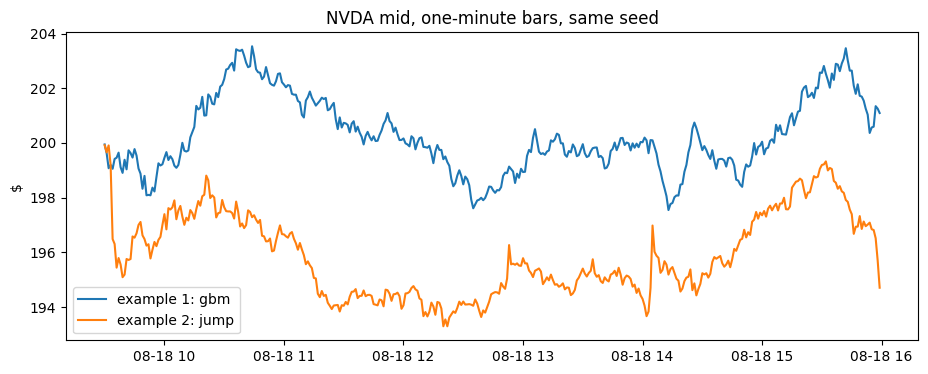

In [8]:
print('baseintensity gbm :', round(kx.q('cfg1`baseintensity').py(), 4))
print('baseintensity jump:', round(kx.q('cfg2`baseintensity').py(), 4))
kx.q('r2:simtick.run cfg2')
kx.q('t2:select from r2`trade where cond in `R`I')
kx.q('q2:r2`quote')
print('continuous trades:', kx.q('count t2').py())
kx.q('m2:select mid:last 0.5*bid+ask by 0D00:01 xbar time from q2')
mid2 = kx.q('m2').pd()
plt.figure(figsize=(11,4)); plt.plot(mid.index, mid['mid'], label='example 1: gbm'); plt.plot(mid2.index, mid2['mid'], label='example 2: jump')
plt.legend(); plt.title('NVDA mid, one-minute bars, same seed'); plt.ylabel('$'); plt.show()

### Where the jumps are

A jump shows as a one-minute return several times larger than the diffusion produces (about 0.13% per minute at 42% annual vol), followed by a burst of trades that fades over the next minutes.

In [9]:
# one-minute returns above 0.8%: several times what the diffusion produces in a minute
kx.q('jumps:select time,ret from (0!update ret:-1+mid%prev mid from m2) where 0.008<abs ret')
display(kx.q('jumps').pd())

# the number of jumps is random (Poisson, 3 on average) and a small jump can stay under 0.8%,
# so a day may show none: try another seed in run1 if the table above is empty
if kx.q('count jumps').py() > 0:
    # trades per minute around the first jump, against the same minutes in example 1
    kx.q('t0:first jumps`time')
    kx.q('w:select trades_jump:count i by 0D00:01 xbar time from t2 where time within (t0-0D00:03;t0+0D00:06)')
    kx.q('v:select trades_gbm:count i by 0D00:01 xbar time from t1 where time within (t0-0D00:03;t0+0D00:06)')
    display(kx.q('w lj v').pd())
else:
    print('no one-minute move above 0.8% on this day')


,time,ret
0,2026-08-18 09:34:00,-0.01358
1,2026-08-18 14:05:00,0.01171


,trades_jump,trades_gbm
time,,
2026-08-18 09:31:00,103,91
2026-08-18 09:32:00,81,66
2026-08-18 09:33:00,95,76
2026-08-18 09:34:00,214,81
2026-08-18 09:35:00,246,88
2026-08-18 09:36:00,146,48
2026-08-18 09:37:00,138,70
2026-08-18 09:38:00,67,75
2026-08-18 09:39:00,89,68


## Recap

- To simulate a stock on a day, give the five instrument values and the date: `simtick.quick[sym;price;drift;vol;tradesperday;tradingdate]`.
- To change the kind of day (jumps, a volatile day, a wider spread), change or override the **scenario** row.
- To change how the market works (bursts, venues, sizes, spreads), change or override the **market** file; an instrument dictionary may override any market key, as `jumpburst` was here.
- To change the seed or leave the quotes out, pass a **run** dictionary: `simtick.quickwith[`NVDA;200.0;0.01;0.42;20000;2026.08.18;(enlist `seed)!enlist 7]`.
- A composed configuration can be saved and replayed exactly: `simtick.saveconfig[`:nvda_jump.json;cfg2]` and `simtick.loadconfig`:nvda_jump.json`.

Every parameter, with its layer and group, is listed in [docs/parameters.md](../docs/parameters.md).